Running simulation with 10,000 genes...
Specificity Bias Analysis

Distribution Statistics:
                 total_umi specificity                         true_fraction
                     first        mean  median     std     max          mean
celltype                                                                    
Large_neurons      1000000      0.9735  0.7559  0.8351  4.8971        0.2000
Medium_glia         500000      0.9732  0.7482  0.8429  4.9192        0.1995
Small_astrocytes    100000      0.9524  0.7364  0.8365  5.0000        0.1984
Tiny_choroid         20000      1.0015  0.6545  0.8749  4.8077        0.2015
Very_tiny             5000      1.0979  1.4184  1.1132  4.6566        0.2001

Bias Analysis (deviation from expected value of 1.0):
-------------------------------------------------------
Large_neurons       : Bias = -0.027 ( -2.7%), UMI =  1000000, 39.2% > 1.0
Medium_glia         : Bias = -0.027 ( -2.7%), UMI =   500000, 38.6% > 1.0
Small_astrocytes    : Bias = -0.0

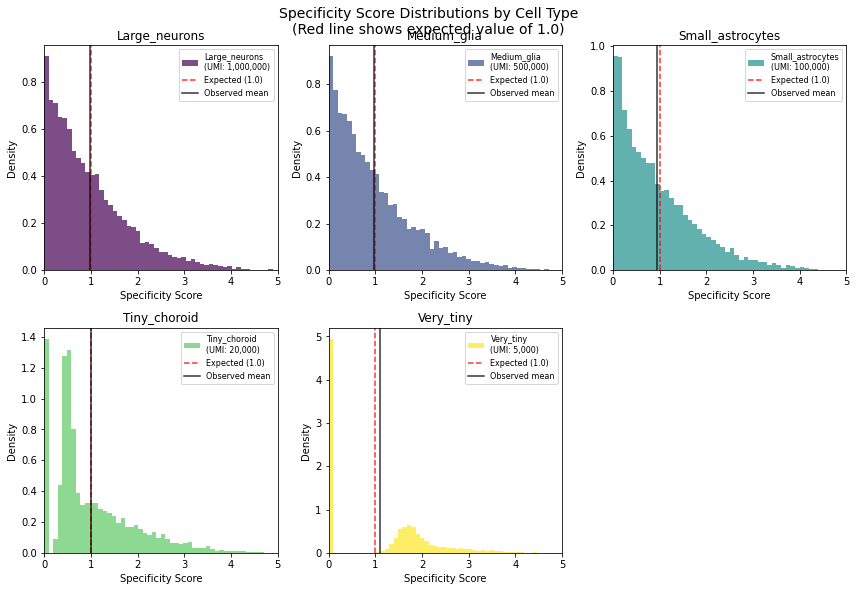


Key Findings:
1. Small cell types (low total UMI) show systematic bias toward higher specificity
2. This bias occurs due to minimum UMI detection threshold (=1)
3. However, as you noted, p-values remain valid because:
   - Both disease genes AND random genes experience the same bias
   - Permutation testing compares relative rankings within each cell type
   - The statistical comparison is 'apples-to-apples'

4. The paper's conclusions about CGE interneurons remain valid!


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def simulate_specificity_bias(n_genes=10000, seed=42):
    """
    Simulate specificity calculation bias due to cell type size differences

    This demonstrates how the TPM-based specificity calculation in the paper
    creates systematic bias toward smaller cell types due to:
    1. Minimum UMI detection threshold (=1)
    2. Smaller denominators in TPM calculation
    3. Poisson noise in low-expression genes
    """
    np.random.seed(seed)

    # Cell types with different total UMI counts (mimicking real data)
    celltype_names = ['Large_neurons', 'Medium_glia', 'Small_astrocytes', 'Tiny_choroid', 'Very_tiny']
    total_umis = np.array([1000000, 500000, 100000, 20000, 5000])
    n_celltypes = len(celltype_names)

    results = []

    for gene_idx in range(n_genes):
        # Generate true expression fractions (ground truth)
        if gene_idx % 1000 == 0:  # 0.1% truly specific genes
            true_fractions = np.zeros(n_celltypes)
            specific_idx = np.random.randint(0, n_celltypes)
            true_fractions[specific_idx] = 0.96
            true_fractions[1-specific_idx:] = 0.01  # Small background
        else:
            # Random expression pattern
            true_fractions = np.random.dirichlet(np.ones(n_celltypes))

        # Calculate expected UMI counts
        expected_umis = true_fractions * total_umis * 0.0005  # Scale factor

        # Simulate observed UMI with Poisson noise + minimum detection
        observed_umis = np.zeros(n_celltypes)
        for i in range(n_celltypes):
            if expected_umis[i] < 0.5:
                # Low expression: might not be detected
                observed_umis[i] = 1 if np.random.random() < expected_umis[i] else 0
            else:
                # Higher expression: Poisson with minimum of 1
                observed_umis[i] = max(1, np.random.poisson(expected_umis[i]))

        # Calculate TPM (following paper's method)
        tpms = np.zeros(n_celltypes)
        for i in range(n_celltypes):
            if observed_umis[i] > 0:
                tpm = max(0.1, (observed_umis[i] / total_umis[i]) * 1e6)
            else:
                tpm = 0.0
            tpms[i] = tpm

        # Calculate specificity scores (Equation 2 from paper)
        total_tpm = np.sum(tpms)
        if total_tpm > 0:
            specificities = n_celltypes * (tpms / total_tpm)
        else:
            specificities = np.zeros(n_celltypes)

        # Store results
        for i in range(n_celltypes):
            results.append({
                'gene': gene_idx,
                'celltype': celltype_names[i],
                'total_umi': total_umis[i],
                'true_fraction': true_fractions[i],
                'expected_umi': expected_umis[i],
                'observed_umi': observed_umis[i],
                'tpm': tpms[i],
                'specificity': specificities[i]
            })

    return pd.DataFrame(results)

def analyze_bias(df):
    """Analyze the systematic bias in specificity calculations"""

    print("Specificity Bias Analysis")
    print("=" * 50)

    # Group by cell type and analyze distributions
    summary = df.groupby('celltype').agg({
        'total_umi': 'first',
        'specificity': ['mean', 'median', 'std', 'max'],
        'true_fraction': 'mean'
    }).round(4)

    print("\nDistribution Statistics:")
    print(summary)

    # Calculate bias relative to expected value (1.0)
    print("\nBias Analysis (deviation from expected value of 1.0):")
    print("-" * 55)

    bias_analysis = []
    for celltype in df['celltype'].unique():
        subset = df[df['celltype'] == celltype]
        mean_spec = subset['specificity'].mean()
        total_umi = subset['total_umi'].iloc[0]
        bias = mean_spec - 1.0
        bias_pct = (bias / 1.0) * 100

        # Count genes with specificity > 1.0 (above expected)
        above_expected = (subset['specificity'] > 1.0).sum()
        total_genes = len(subset)
        pct_above = (above_expected / total_genes) * 100

        bias_analysis.append({
            'celltype': celltype,
            'total_umi': total_umi,
            'mean_specificity': mean_spec,
            'bias': bias,
            'bias_percent': bias_pct,
            'percent_above_1.0': pct_above
        })

        print(f"{celltype:20s}: Bias = {bias:+.3f} ({bias_pct:+5.1f}%), "
              f"UMI = {total_umi:8d}, {pct_above:.1f}% > 1.0")

    return pd.DataFrame(bias_analysis)

def plot_distributions(df, save_plot=False):
    """Create density plots showing the bias"""
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(12, 8))

    # Create density plots for each cell type
    cell_types = df['celltype'].unique()
    colors = plt.cm.viridis(np.linspace(0, 1, len(cell_types)))

    for i, celltype in enumerate(cell_types):
        subset = df[df['celltype'] == celltype]
        total_umi = subset['total_umi'].iloc[0]

        plt.subplot(2, 3, i+1)
        plt.hist(subset['specificity'], bins=50, alpha=0.7, density=True,
                 color=colors[i], label=f'{celltype}\n(UMI: {total_umi:,})')
        plt.axvline(x=1.0, color='red', linestyle='--', alpha=0.8,
                    label='Expected (1.0)')
        plt.axvline(x=subset['specificity'].mean(), color='black',
                    linestyle='-', alpha=0.8, label='Observed mean')

        plt.xlabel('Specificity Score')
        plt.ylabel('Density')
        plt.title(f'{celltype}')
        plt.legend(fontsize=8)
        plt.xlim(0, 5)

    plt.tight_layout()
    plt.suptitle('Specificity Score Distributions by Cell Type\n(Red line shows expected value of 1.0)',
                 y=1.02, fontsize=14)

    if save_plot:
        plt.savefig('specificity_bias_simulation.png', dpi=300, bbox_inches='tight')

    plt.show()

def demonstrate_extreme_case():
    """Show extreme case where minimum UMI detection creates strong bias"""

    print("\nExtreme Case Demonstration:")
    print("=" * 40)
    print("Gene with very low true expression, all cell types hit minimum UMI = 1")

    celltype_names = ['Large_neurons', 'Medium_glia', 'Small_astrocytes', 'Tiny_choroid', 'Very_tiny']
    total_umis = np.array([1000000, 500000, 100000, 20000, 5000])

    # All cell types get exactly 1 UMI (minimum detection)
    observed_umis = np.ones(5)

    # Calculate TPM and specificity
    tpms = (observed_umis / total_umis) * 1e6
    total_tpm = np.sum(tpms)
    specificities = 5 * (tpms / total_tpm)

    print(f"{'Cell Type':20s} {'Total UMI':>10s} {'TPM':>10s} {'Specificity':>12s} {'Fold Bias':>10s}")
    print("-" * 70)

    for i, celltype in enumerate(celltype_names):
        fold_bias = specificities[i] / 1.0  # Expected is 1.0
        print(f"{celltype:20s} {total_umis[i]:10,d} {tpms[i]:10.2f} "
              f"{specificities[i]:12.3f} {fold_bias:10.2f}x")

# Run the complete simulation
if __name__ == "__main__":
    # Generate data
    print("Running simulation with 10,000 genes...")
    df = simulate_specificity_bias(n_genes=10000)

    # Analyze bias
    bias_df = analyze_bias(df)

    # Show extreme case
    demonstrate_extreme_case()

    # Create plots
    plot_distributions(df, save_plot=True)

    print("\nKey Findings:")
    print("=" * 40)
    print("1. Small cell types (low total UMI) show systematic bias toward higher specificity")
    print("2. This bias occurs due to minimum UMI detection threshold (=1)")
    print("3. However, as you noted, p-values remain valid because:")
    print("   - Both disease genes AND random genes experience the same bias")
    print("   - Permutation testing compares relative rankings within each cell type")
    print("   - The statistical comparison is 'apples-to-apples'")
    print("\n4. The paper's conclusions about CGE interneurons remain valid!")

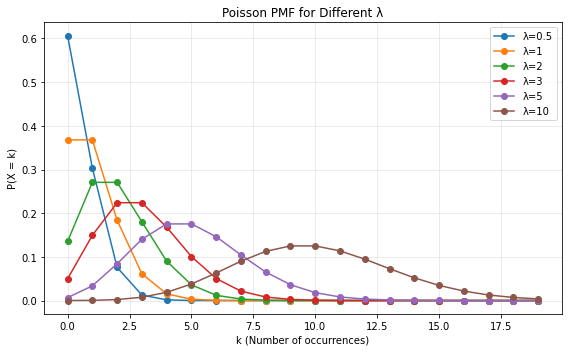

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Plot the Poisson model for several lambda values
lambdas = [0.5, 1, 2, 3, 5, 10]
k = np.arange(0, 20)

plt.figure(figsize=(8, 5))
for lam in lambdas:
    pmf = poisson.pmf(k, lam)
    plt.plot(k, pmf, marker='o', label=f'λ={lam}')

plt.title('Poisson PMF for Different λ')
plt.xlabel('k (Number of occurrences)')
plt.ylabel('P(X = k)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# ---------------------------
# Default parameters
# ---------------------------
DEFAULT_N_CELL_TYPES = 100     # Number of cell types
DEFAULT_N_CELLS = 1000         # Cells per type
DEFAULT_N_GENES = 1            # Simulating a single gene
DEFAULT_UMI_RANGE = (2000, 1000000)  # Range for total UMIs per cell type
DEFAULT_MIN_DETECT = 1         # Minimum detectable UMI
DEFAULT_N_REPS = 200           # Replicates for averaging
DEFAULT_SEED = 42              # RNG seed


# ---------------------------
# Generate per-cell-type gene fractions (no cross-normalization)
# ---------------------------
def generate_real_fractions(n_cell_types, frac=None, default_level=1e-4):
    """
    Return gene expression fractions for each cell type (fraction of total UMI within each type).
    If `frac` is provided, use it directly; otherwise, generate small random fractions.
    No normalization across cell types is done.
    """
    if frac is None:
        frac = np.random.uniform(default_level / DEFAULT_N_CELL_TYPES, default_level * DEFAULT_N_CELL_TYPES, n_cell_types)
    else:
        frac = np.array(frac)
    return frac


# ---------------------------
# Simulate per-cell total UMIs for each cell type
# ---------------------------
def simulate_total_umis(n_cells, cluster_mean, umi_range):
    """
    Simulate total UMI for each cell using a lognormal distribution.
    Clip to stay within umi_range.
    """
    totals = np.random.lognormal(mean=np.log(cluster_mean), sigma=0.3, size=n_cells)
    return np.clip(totals, umi_range[0], umi_range[1])


# ---------------------------
# Simulate gene UMI counts per cell (Poisson sampling)
# ---------------------------
def simulate_gene_counts(real_frac, total_umis, min_detect):
    """
    Poisson sampling for a single gene given its fraction and total UMIs.
    Counts below `min_detect` are set to 0.
    """
    lam = real_frac * total_umis
    counts = np.random.poisson(lam)
    counts[counts < min_detect] = 0
    return counts


# ---------------------------
# Compute TPM for a gene in each cell type
# ---------------------------
def compute_tpm(gene_counts, total_umis):
    """
    TPM = (gene_counts / total_UMIs) * 1e6 for each cell type.
    """
    return (gene_counts / (total_umis + 1e-12)) * 1e6


# ---------------------------
# Compute specificity score (Eq. 2 from paper)
# ---------------------------
def compute_specificity(tpm, cap=2.0):
    """
    Specificity = TPM / mean(TPM across cell types), capped at `cap`.
    """
    mean_tpm = tpm.mean()
    return np.clip(tpm / (mean_tpm + 1e-12), None, cap)


# ---------------------------
# Main simulation: one gene across multiple cell types
# ---------------------------
def simulate_gene_specificity(
    n_cell_types=DEFAULT_N_CELL_TYPES,
    n_cells_per_type=DEFAULT_N_CELLS,
    umi_range=DEFAULT_UMI_RANGE,
    real_frac=None,                 # per-cell-type fractions (not normalized)
    min_detect=DEFAULT_MIN_DETECT,
    n_reps=DEFAULT_N_REPS,
    seed=DEFAULT_SEED
):
    """
    Simulate specificity scores for a single gene across cell types,
    with per-cell UMI variation, Poisson sampling, and detection threshold.
    Returns mean ± SD specificity per cell type across replicates.
    """
    np.random.seed(seed)
    frac = generate_real_fractions(n_cell_types, real_frac)
    
    # Random total UMIs for each cell type
    total_umi_types = np.random.uniform(umi_range[0], umi_range[1], n_cell_types)
    specificity_results = []
    
    for _ in range(n_reps):
        gene_ct_means = []
        total_ct_means = []
        
        for ct in range(n_cell_types):
            # Simulate total UMIs per cell
            total_umis_per_cell = simulate_total_umis(n_cells_per_type, total_umi_types[ct], umi_range)
            # Simulate gene counts for all cells
            gene_counts_cells = simulate_gene_counts(frac[ct], total_umis_per_cell, min_detect)
            
            # Average counts and total UMIs per cell type
            gene_ct_means.append(gene_counts_cells.mean())
            total_ct_means.append(total_umis_per_cell.mean())
        
        gene_ct_means = np.array(gene_ct_means)
        total_ct_means = np.array(total_ct_means)
        
        # Compute TPM and specificity
        tpm = compute_tpm(gene_ct_means, total_ct_means)
        spec = compute_specificity(tpm)
        specificity_results.append(spec)
    
    specificity_results = np.array(specificity_results)
    
    return {
        "real_frac": frac,
        "total_umi_types": total_umi_types,
        "mean_spec": specificity_results.mean(axis=0),
        "std_spec": specificity_results.std(axis=0)
    }


# ---------------------------
# Plotting helper
# ---------------------------
def plot_specificity_vs_umi(result, title="Specificity vs Total UMI (single gene)"):
    plt.errorbar(result["total_umi_types"], result["mean_spec"],
                 yerr=result["std_spec"], fmt='o', capsize=3)
    plt.xlabel("Total UMI per Cell Type")
    plt.ylabel("Specificity Score")
    plt.title(title)
    plt.show()

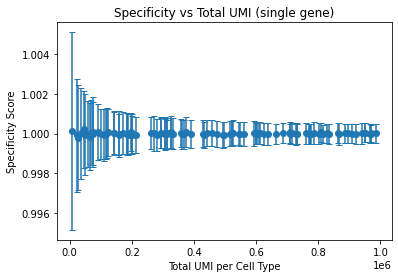

In [41]:
real_frac = [1/200] * DEFAULT_N_CELL_TYPES
result = simulate_gene_specificity(real_frac=real_frac, n_reps=300)

plot_specificity_vs_umi(result)

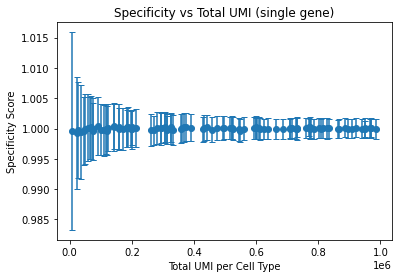

In [42]:
real_frac = [1/2000] * DEFAULT_N_CELL_TYPES
result = simulate_gene_specificity(real_frac=real_frac, n_reps=300)

plot_specificity_vs_umi(result)

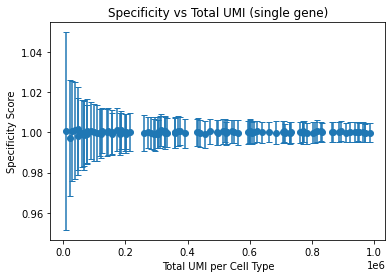

In [43]:
real_frac = [1/20000] * DEFAULT_N_CELL_TYPES
result = simulate_gene_specificity(real_frac=real_frac, n_reps=300)

plot_specificity_vs_umi(result)

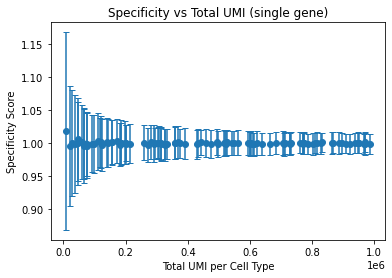

In [44]:
real_frac = [1/200000] * DEFAULT_N_CELL_TYPES
result = simulate_gene_specificity(real_frac=real_frac, n_reps=300)

plot_specificity_vs_umi(result)

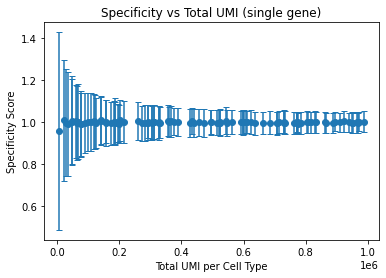

In [45]:
real_frac = [1/2000000] * DEFAULT_N_CELL_TYPES
result = simulate_gene_specificity(real_frac=real_frac, n_reps=300)

plot_specificity_vs_umi(result)

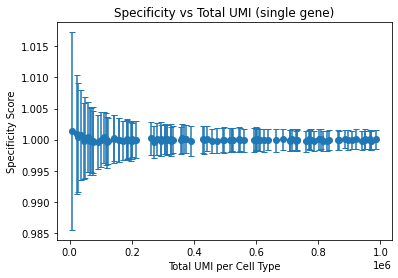

In [47]:
real_frac = [1/20000] * DEFAULT_N_CELL_TYPES
result = simulate_gene_specificity(real_frac=real_frac, n_reps=300, n_cells_per_type=10000)

plot_specificity_vs_umi(result)

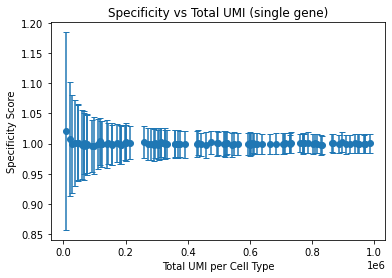

In [48]:
real_frac = [1/20000] * DEFAULT_N_CELL_TYPES
result = simulate_gene_specificity(real_frac=real_frac, n_reps=300, n_cells_per_type=100)

plot_specificity_vs_umi(result)